In [3]:
#Load Dataset

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("churn.csv")

print(df.head())
print(df.columns)

   customer_id  credit_score country  gender  age  tenure    balance  \
0     15634602           619  France  Female   42       2       0.00   
1     15647311           608   Spain  Female   41       1   83807.86   
2     15619304           502  France  Female   42       8  159660.80   
3     15701354           699  France  Female   39       1       0.00   
4     15737888           850   Spain  Female   43       2  125510.82   

   products_number  credit_card  active_member  estimated_salary  churn  
0                1            1              1         101348.88      1  
1                1            0              1         112542.58      0  
2                3            1              0         113931.57      1  
3                2            0              0          93826.63      0  
4                1            1              1          79084.10      0  
Index(['customer_id', 'credit_score', 'country', 'gender', 'age', 'tenure',
       'balance', 'products_number', 'credit_ca

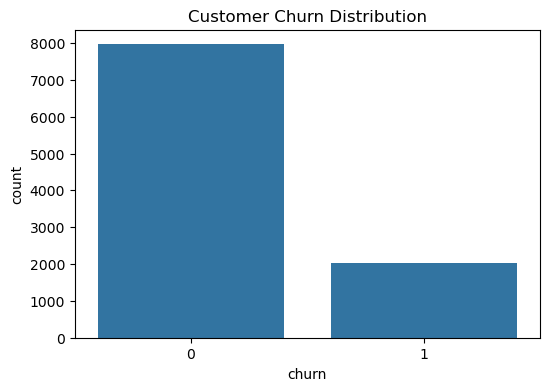

In [4]:
#Churn Distribution Graph

plt.figure(figsize=(6,4))

sns.countplot(x="churn", data=df)

plt.title("Customer Churn Distribution")

plt.savefig("churn_distribution.png")

plt.show()

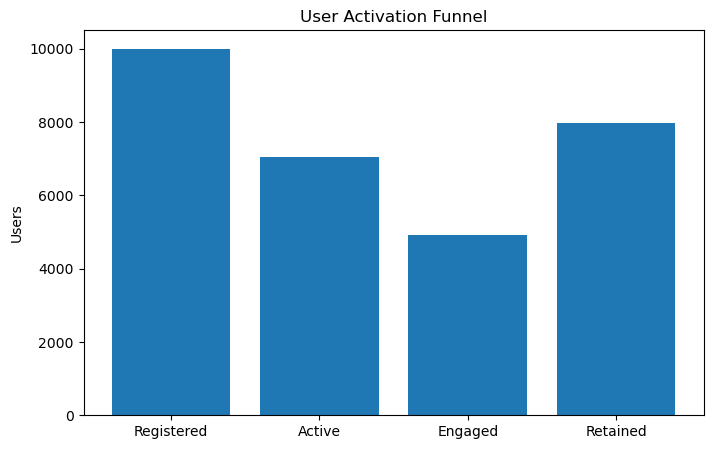

In [5]:
#Funnel Chart

funnel = {
'Registered': len(df),
'Active': len(df[df['credit_card']==1]),
'Engaged': len(df[df['products_number']>=2]),
'Retained': len(df[df['churn']==0])
}

plt.figure(figsize=(8,5))

plt.bar(funnel.keys(), funnel.values())

plt.title("User Activation Funnel")
plt.ylabel("Users")

plt.savefig("funnel.png")

plt.show()

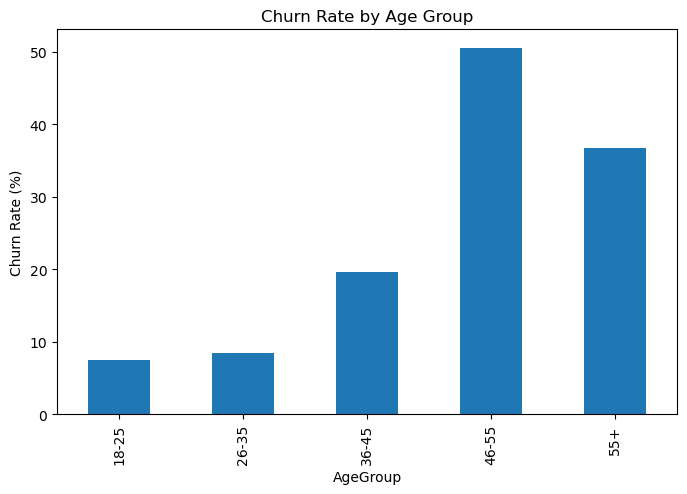

In [6]:
#Cohort Analysis

df['AgeGroup'] = pd.cut(
df['age'],
bins=[18,25,35,45,55,100],
labels=['18-25','26-35','36-45','46-55','55+']
)

cohort = df.groupby('AgeGroup', observed=False)['churn'].mean()*100

plt.figure(figsize=(8,5))

cohort.plot(kind='bar')

plt.title("Churn Rate by Age Group")
plt.ylabel("Churn Rate (%)")

plt.savefig("cohort_churn.png")

plt.show()

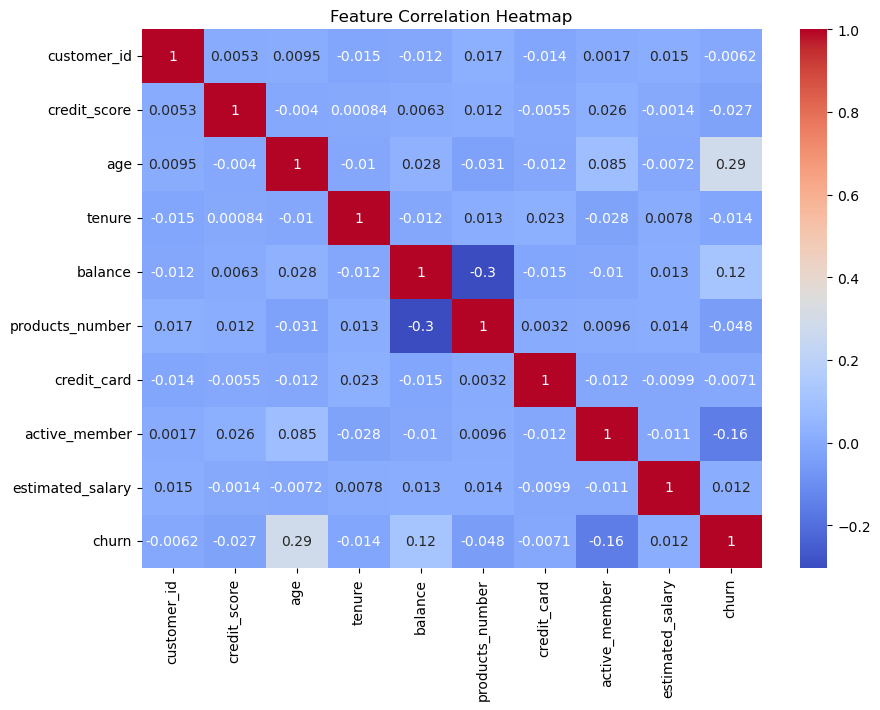

In [7]:
#Correlation Heatmap

plt.figure(figsize=(10,7))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")

plt.title("Feature Correlation Heatmap")

plt.savefig("churn_heatmap.png")

plt.show()

In [8]:
#Confirm Images Saved

import os
print(os.listdir())

['.ipynb_checkpoints', 'churn.csv', 'churn_analysis.ipynb', 'churn_distribution.png', 'churn_heatmap.png', 'cohort_churn.png', 'funnel.png']
